In [1]:
import numpy as np
import matplotlib.pyplot as plt
from Bio import motifs
from Bio.Seq import Seq

In [2]:
sites = ["GAGGTAAAC", "TCCGTAAGC", "CAGGTTGGA",
         "ACAGTCAGC", "TAGGTCAGC", "CAGGTCAGC",
         "CAGGTCGAT", "CAGGTCAGC", "CAGGTCAGC",
         "CAGGTTGGC"]

In [3]:
instances = [Seq(site) for site in sites]
m = motifs.create(instances)
ppm = m.counts.normalize(pseudocounts=0.1)

Введем ф-цию для расчета энтропии:

In [4]:
def entropy(pos):
    H = 0
    for base in "ATGC":
        p = ppm[base][pos]
        if p > 0:
            H -= p * np.log2(p)
    return H

Рассчитаем энтропии и информационное содержание:

In [6]:
H = [entropy(i) for i in range(len(sites[0]))]
IC = [2 - h for h in H]

Построим bar chart с номерами позиций и их информационным содержанием:

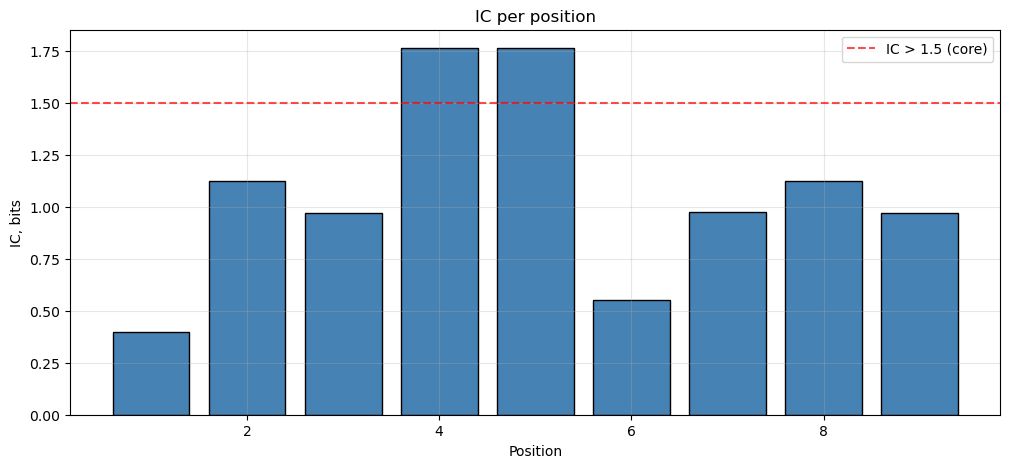

In [9]:
plt.figure(figsize=(12, 5))
plt.bar(range(1, len(IC)+1), IC, color='steelblue', edgecolor='black')
plt.axhline(y=1.5, color='red', linestyle='--', alpha=0.7, label='IC > 1.5 (core)')
plt.xlabel('Position')
plt.ylabel('IС, bits')
plt.title('IС per position')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
for i, ic in enumerate(IC, 1):
    consensus = max(ppm.keys(), key=lambda b: ppm[b][i-1])
    print(f"{i}\t\t{ic:.3f}\t{consensus}")

core = [i+1 for i, ic in enumerate(IC) if ic > 1.5]
variable = [i+1 for i, ic in enumerate(IC) if ic <= 1.5]

print(f"\nCore motif positions (IC > 1.5): {core}")
print(f"Variable positions (IC ≤ 1.5): {variable}")

1		0.397	C
2		1.124	A
3		0.969	G
4		1.766	G
5		1.766	T
6		0.552	C
7		0.975	A
8		1.124	G
9		0.969	C

Core motif positions (IC > 1.5): [4, 5]
Variable positions (IC ≤ 1.5): [1, 2, 3, 6, 7, 8, 9]


In [11]:
print('Визуально посмотрим на выравнивания:')
for i, site in enumerate(sites):
    print(f"{i+1:2d}. {site}")

Визуально посмотрим на выравнивания:
 1. GAGGTAAAC
 2. TCCGTAAGC
 3. CAGGTTGGA
 4. ACAGTCAGC
 5. TAGGTCAGC
 6. CAGGTCAGC
 7. CAGGTCGAT
 8. CAGGTCAGC
 9. CAGGTCAGC
10. CAGGTTGGC


Как можно отметить, позиции 4 и 5 имеют высокий IC (IC > 1.5), а значит они и являются "кор-мотивами". Т.к. они консервативны для всех посл-тей. Это также заметно при визуальном сравнении. Позиции же 1, 2, 3. 6, 7, 8 и 9 - вариабельны.